In [5]:
from pathlib import Path 
import numpy as np
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.utils import to_categorical

In [ ]:
# ===============================
# 1. Cargar datos procesados
# ===============================

PROJECT_ROOT = Path().resolve().parent
PROCESSED_PATH = PROJECT_ROOT / "data" / "processed"

# Cargar split de entrenamiento
X_train = np.load(PROCESSED_PATH / "train" / "X.npy")
y_train = np.load(PROCESSED_PATH / "train" / "y.npy")

# Cargar validación
X_val = np.load(PROCESSED_PATH / "val" / "X.npy")
y_val = np.load(PROCESSED_PATH / "val" / "y.npy")

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Pixel range:", X_train.min(), X_train.max())

Train shape: (6482, 128, 128, 3)
Validation shape: (1388, 128, 128, 3)
Pixel range: 0.0 1.0


In [7]:
# ===============================
# 2. Parámetros principales
# ===============================

input_shape = (128, 128, 3)
latent_dim = 16   # pequeño para empezar simple

### Encoder

In [8]:
# ===============================
# 3. Encoder
# ===============================

encoder_inputs = layers.Input(shape=input_shape)

x = layers.Conv2D(32, 3, strides=2, padding="same", activation="relu")(encoder_inputs)  # 64x64
x = layers.Conv2D(64, 3, strides=2, padding="same", activation="relu")(x)              # 32x32
x = layers.Conv2D(128, 3, strides=2, padding="same", activation="relu")(x)             # 16x16

x = layers.Flatten()(x)
x = layers.Dense(128, activation="relu")(x)

# Media y log varianza
z_mean = layers.Dense(latent_dim)(x)
z_log_var = layers.Dense(latent_dim)(x)

In [9]:
# ===============================
# 4. Sampling
# ===============================

def sampling(args):
    z_mean, z_log_var = args
    epsilon = tf.random.normal(shape=tf.shape(z_mean))
    return z_mean + tf.exp(0.5 * z_log_var) * epsilon

z = layers.Lambda(sampling)([z_mean, z_log_var])

In [10]:
# ===============================
# 5. Decoder
# ===============================

decoder_inputs = layers.Input(shape=(latent_dim,))

x = layers.Dense(16*16*128, activation="relu")(decoder_inputs)
x = layers.Reshape((16,16,128))(x)

x = layers.Conv2DTranspose(128, 3, strides=2, padding="same", activation="relu")(x)  # 32x32
x = layers.Conv2DTranspose(64, 3, strides=2, padding="same", activation="relu")(x)   # 64x64
x = layers.Conv2DTranspose(32, 3, strides=2, padding="same", activation="relu")(x)   # 128x128

decoder_outputs = layers.Conv2D(3, 3, padding="same", activation="sigmoid")(x)

decoder = Model(decoder_inputs, decoder_outputs, name="decoder")

In [13]:
# ===============================
# 7. Función de pérdida (VAE Layer)
# ===============================

class VAELossLayer(tf.keras.layers.Layer):
    def call(self, inputs):
        y_true, y_pred, z_mean, z_log_var = inputs
        
        # Reconstruction loss (pixel-wise BCE)
        reconstruction_loss = tf.reduce_mean(
            tf.keras.losses.binary_crossentropy(y_true, y_pred),
            axis=(1, 2)
        ) * input_shape[0] * input_shape[1]

        # KL divergence
        kl_loss = -0.5 * tf.reduce_sum(
            1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var),
            axis=-1
        )

        total_loss = tf.reduce_mean(reconstruction_loss + kl_loss)

        self.add_loss(total_loss)
        return y_pred

In [14]:
# ===============================
# 6. Modelo VAE completo
# ===============================

encoder = Model(encoder_inputs, [z_mean, z_log_var, z], name="encoder")

z_mean, z_log_var, z = encoder(encoder_inputs)
reconstructed = decoder(z)

# Aplicar capa de pérdida
vae_output = VAELossLayer()([encoder_inputs, reconstructed, z_mean, z_log_var])

vae = Model(encoder_inputs, vae_output, name="VAE")
vae.compile(optimizer=tf.keras.optimizers.Adam())

In [15]:
# ===============================
# 8. Entrenamiento
# ===============================

history = vae.fit(
    X_train,
    X_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_val, X_val)
)

Epoch 1/20
203/203 ━━━━━━━━━━━━━━━━━━━━ 53s 249ms/step - loss: 10108.2334 - val_loss: 9438.2021
Epoch 2/20
203/203 ━━━━━━━━━━━━━━━━━━━━ 51s 250ms/step - loss: 9339.9023 - val_loss: 9303.2734
Epoch 3/20
203/203 ━━━━━━━━━━━━━━━━━━━━ 51s 252ms/step - loss: 9224.9990 - val_loss: 9256.2529
Epoch 4/20
203/203 ━━━━━━━━━━━━━━━━━━━━ 77s 226ms/step - loss: 9169.0049 - val_loss: 9191.8691
Epoch 5/20
203/203 ━━━━━━━━━━━━━━━━━━━━ 50s 247ms/step - loss: 9137.1689 - val_loss: 9155.4609
Epoch 6/20
203/203 ━━━━━━━━━━━━━━━━━━━━ 49s 240ms/step - loss: 9120.5830 - val_loss: 9153.1221
Epoch 7/20
203/203 ━━━━━━━━━━━━━━━━━━━━ 54s 268ms/step - loss: 9106.4619 - val_loss: 9145.8896
Epoch 8/20
203/203 ━━━━━━━━━━━━━━━━━━━━ 53s 263ms/step - loss: 9098.1064 - val_loss: 9134.4121
Epoch 9/20
203/203 ━━━━━━━━━━━━━━━━━━━━ 49s 239ms/step - loss: 9090.0527 - val_loss: 9131.6602
Epoch 10/20
203/203 ━━━━━━━━━━━━━━━━━━━━ 48s 237ms/step - loss: 9080.4316 - val_loss: 9125.0166
Epoch 11/20
203/203 ━━━━━━━━━━━━━━━━━━━━ 49s 243

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step


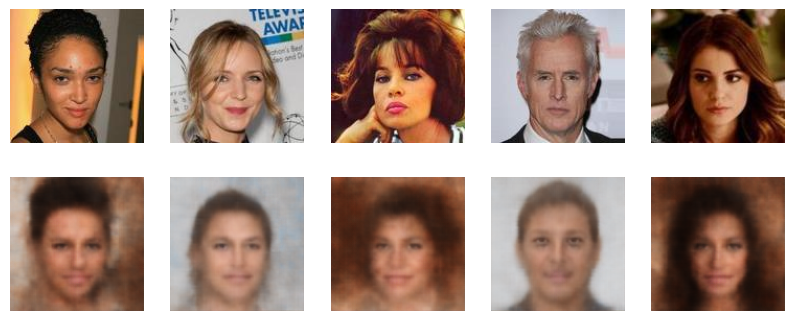

In [16]:
# ===============================
# 9. Visualizar reconstrucciones
# ===============================

import matplotlib.pyplot as plt

recon = vae.predict(X_val[:5])

plt.figure(figsize=(10,4))

for i in range(5):
    # Original
    plt.subplot(2,5,i+1)
    plt.imshow(X_val[i])
    plt.axis("off")
    
    # Reconstruida
    plt.subplot(2,5,i+6)
    plt.imshow(recon[i])
    plt.axis("off")

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step


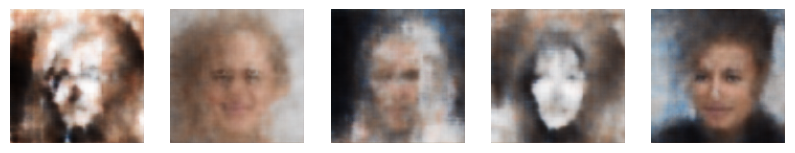

In [17]:
# ===============================
# 10. Generar caras nuevas
# ===============================

random_latent = np.random.normal(size=(5, latent_dim))
generated_images = decoder.predict(random_latent)

plt.figure(figsize=(10,2))

for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(generated_images[i])
    plt.axis("off")

plt.show()